In [2]:
import os
import numpy as np
import librosa
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping


c:\Users\Nandika\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\util\files.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
c:\Users\Nandika\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}


In [4]:
def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=None)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = np.mean(mfcc.T, axis=0)

    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma = np.mean(chroma.T, axis=0)

    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel = np.mean(mel.T, axis=0)

    return np.hstack([mfcc, chroma, mel])


In [5]:
X = []
y = []

dataset_path = "ravdness"   # <-- change if needed

total_audio = 0

for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            emotion_code = file.split("-")[2]
            emotion = emotion_dict.get(emotion_code)

            if emotion:
                file_path = os.path.join(root, file)
                features = extract_features(file_path)

                X.append(features)
                y.append(emotion)
                total_audio += 1

print("Total audio files loaded:", total_audio)


Total audio files loaded: 1440


In [6]:
X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Labels shape:", y.shape)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

Feature shape: (1440, 180)
Labels shape: (1440,)


In [7]:
X = np.expand_dims(X, axis=2)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)


Final X shape: (1440, 180, 1)
Final y shape: (1440,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_categorical
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 1152
Testing samples: 288


In [9]:
model = Sequential()

model.add(Conv1D(64, kernel_size=5, activation="relu", input_shape=(X.shape[1], 1)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(Conv1D(128, kernel_size=5, activation="relu"))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(len(emotion_dict), activation="softmax"))

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


c:\Users\Nandika\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 176, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 88, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 88, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 84, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 42, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       688,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 730,760 (2.79 MB)

 Trainable params: 730,760 (2.79 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.1927 - loss: 2.4702 - val_accuracy: 0.2708 - val_loss: 1.9236
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.2196 - loss: 1.9653 - val_accuracy: 0.2569 - val_loss: 1.8469
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.2760 - loss: 1.8620 - val_accuracy: 0.3056 - val_loss: 1.7719
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3030 - loss: 1.8307 - val_accuracy: 0.3542 - val_loss: 1.7331
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3229 - loss: 1.7575 - val_accuracy: 0.3333 - val_loss: 1.6801
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3281 - loss: 1.7236 - val_accuracy: 0.3438 - val_loss: 1.6447
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3620 - loss: 1.6580 - val_accuracy: 0.3785 - val_loss: 1.6066
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.3898 - loss: 1.6165 - val_accuracy: 0.4097 - v

In [11]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6979 - loss: 0.8800
Test Accuracy: 69.79%


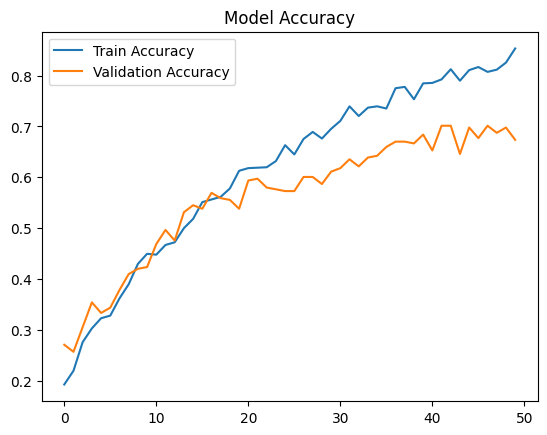

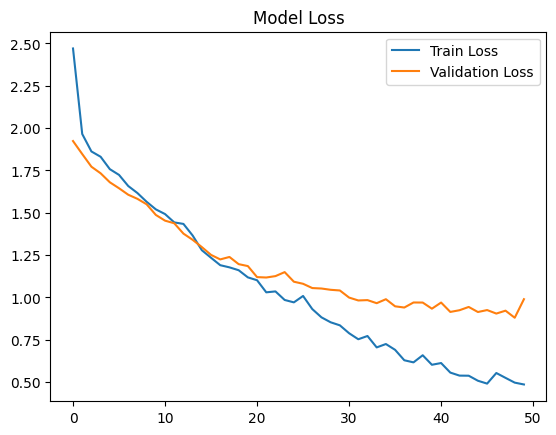

In [12]:
plt.figure()
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Model Accuracy")
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Model Loss")
plt.show()

In [13]:
model.save("emotion_cnn_model.keras")

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [14]:
def predict_emotion(file_path):
    # 1️⃣ Extract features
    features = extract_features(file_path)
    
    # 2️⃣ Reshape for Conv1D (no scaler for now)
    features = np.expand_dims(features, axis=0)  # shape: (1, features)
    features = np.expand_dims(features, axis=2)  # shape: (1, features, 1)

    # 3️⃣ Predict
    prediction = model.predict(features, verbose=0)
    emotion_index = np.argmax(prediction)

    # 4️⃣ Convert index back to label
    return label_encoder.inverse_transform([emotion_index])[0]




In [15]:
test_file = "aarya happy.wav"

predicted_emotion = predict_emotion(test_file)
print("Predicted Emotion:", predicted_emotion)


Predicted Emotion: sad
